In [390]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [391]:
#Load the dataset
df = pd.read_csv('cleaned_data.csv')
df

,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,weekend,black_friday
0,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35.0,99.92,1.0,99.92,Credit Card,01/12/2025,0.0,0,False
1,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40.0,138.03,1.0,138.03,PayPal,24/11/2025,5.0,0,False
2,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25.0,131.00,1.0,131.00,Credit Card,24/11/2025,14.0,0,False
3,18-25,Other,Miami,VIP,P3003,Sports,399.61,40.0,239.77,1.0,239.77,Credit Card,30/11/2025,23.0,1,True
4,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30.0,84.61,2.0,169.22,Debit Card,25/11/2025,2.0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87928,18-25,Female,Los Angeles,Returning,P2790,Clothing,67.82,10.0,61.04,1.0,61.04,Debit Card,28/11/2025,10.0,0,False
87929,26-35,Male,Dallas,New,P6440,Sports,94.86,25.0,71.14,1.0,71.14,PayPal,28/11/2025,8.0,0,False
87930,46-55,Other,Atlanta,New,P1702,Sports,462.86,25.0,347.14,2.0,694.28,Gift Card,28/11/2025,0.0,0,False
87931,56+,Male,Houston,Returning,P3742,Beauty,87.86,15.0,74.68,2.0,149.36,Credit Card,26/11/2025,0.0,0,False


In [392]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87933 entries, 0 to 87932
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age_group         87933 non-null  object 
 1   gender            87933 non-null  object 
 2   city              87933 non-null  object 
 3   customer_segment  87933 non-null  object 
 4   product_id        87933 non-null  object 
 5   product_category  87933 non-null  object 
 6   original_price    87933 non-null  float64
 7   discount_pct      87933 non-null  float64
 8   final_price       87933 non-null  float64
 9   quantity          87933 non-null  float64
 10  purchase_amount   87933 non-null  float64
 11  payment_method    87933 non-null  object 
 12  purchase_date     87933 non-null  object 
 13  purchase_hour     87933 non-null  float64
 14  weekend           87933 non-null  int64  
 15  black_friday      87933 non-null  bool   
dtypes: bool(1), float64(6), int64(1), object

In [393]:
df.describe()

,original_price,discount_pct,final_price,quantity,purchase_amount,purchase_hour,weekend
count,87933.000000,87933.000000,87933.000000,87933.000000,87933.000000,87933.000000,87933.000000
mean,190.839618,26.875235,138.110308,1.446943,199.974367,11.487849,0.248166
std,149.620498,12.325273,106.855002,0.816081,209.929941,6.908195,0.431951
min,5.000000,5.000000,2.070000,1.000000,2.220000,0.000000,0.000000
25%,78.870000,20.000000,56.220000,1.000000,67.860000,5.000000,0.000000
50%,155.960000,25.000000,111.230000,1.000000,138.080000,11.000000,0.000000
75%,259.210000,35.000000,190.140000,2.000000,255.340000,17.000000,0.000000
max,1207.350000,60.000000,499.970000,5.000000,2474.600000,23.000000,1.000000


In [394]:
# Which product categories dominate?
# output: bar chart showing the count of each product category

df['product_category'].unique()
df['product_category'].value_counts()


product_category
Accessories       10149
Footwear          10091
Toys              10049
Books             10023
Beauty             9976
Groceries          9913
Clothing           9909
Sports             9810
Home & Kitchen     5697
Electronics        2316
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

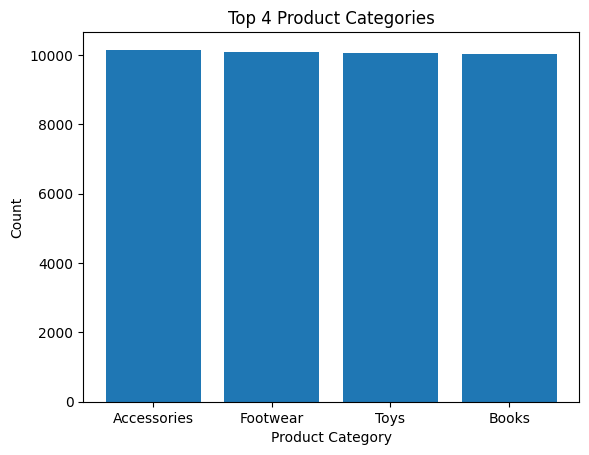

In [395]:
#limit results to top 4
top_4_categories=df['product_category'].value_counts().head(4)
top_4_categories


plt.figure(figsize=(8,5))

fig,ax=plt.subplots()
ax.bar(top_4_categories.index, top_4_categories.values)
ax.set_title('Top 4 Product Categories')
ax.set_xlabel('Product Category')
ax.set_ylabel('Count')
    
plt.show()

In [396]:
top_4_categories.index

Index(['Accessories', 'Footwear', 'Toys', 'Books'], dtype='object', name='product_category')

<Figure size 800x300 with 0 Axes>

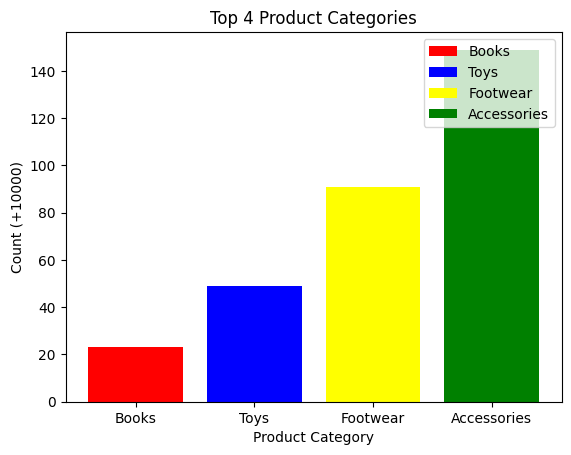

In [397]:
#limit results to top 4
top_4_categories=df['product_category'].value_counts().head(4).sort_values(ascending=True)
top_4_categories


plt.figure(figsize=(8,3)) #initialising the figure and setting the size

fig,ax=plt.subplots() #initialising the axes and figure

colors=['red','blue','yellow','green'] #defining a list of colors for the bars
ax.bar(top_4_categories.index, top_4_categories.values-10000, label=top_4_categories.index, color=colors) #plotting the bar chart using the axes object
ax.set_title('Top 4 Product Categories') # figure/chart title
ax.set_xlabel('Product Category')#x axis label
ax.set_ylabel('Count (+10000)') #y axis label

ax.legend(loc='upper right') #adding legend to the figure
    
plt.show() #plot the figure

product_category
Accessories    10149
Footwear       10091
Toys           10049
Books          10023
Beauty          9976
Name: count, dtype: int64


<Figure size 800x600 with 0 Axes>

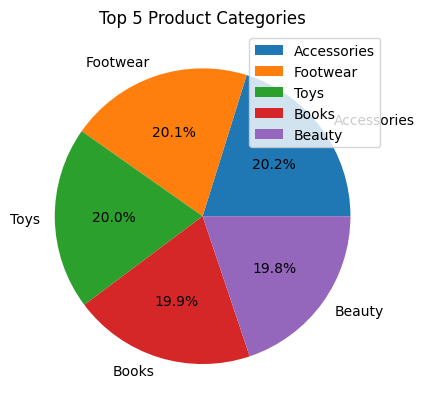

In [398]:
top_5_categories=df['product_category'].value_counts().head(5)
print(top_5_categories)


plt.figure(figsize=(8,6)) #initialising the figure and setting the size

fig,ax=plt.subplots() #initialising the axes and figure
ax.pie(top_5_categories.values, labels=top_5_categories.index, autopct='%1.1f%%') #plotting the pie chart using the axes object
ax.set_title('Top 5 Product Categories') # figure/chart title
ax.legend(loc='upper right') #adding legend to the figure
    
plt.show() #plot the figure

The best selling categories are Accessories , footwear, toys and books when discounted.

In [399]:
df.head()

,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,weekend,black_friday
0,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35.0,99.92,1.0,99.92,Credit Card,01/12/2025,0.0,0,False
1,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40.0,138.03,1.0,138.03,PayPal,24/11/2025,5.0,0,False
2,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25.0,131.00,1.0,131.00,Credit Card,24/11/2025,14.0,0,False
3,18-25,Other,Miami,VIP,P3003,Sports,399.61,40.0,239.77,1.0,239.77,Credit Card,30/11/2025,23.0,1,True
4,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30.0,84.61,2.0,169.22,Debit Card,25/11/2025,2.0,0,False


In [400]:
#Which product categories benefit most from aggressive discounting? qty sold without discount vs qty sold with discount
cat_with_discount=df[df['black_friday']==True]['product_category'].value_counts()

cat_with_discount.head(4).index



Index(['Books', 'Toys', 'Beauty', 'Clothing'], dtype='object', name='product_category')

In [401]:
#customer segments

df['customer_segment'].value_counts()

customer_segment
Returning    30754
New          26339
Loyal        22089
VIP           8751
Name: count, dtype: int64

In [402]:
#average qty bought by each customer segment - average qty per transaction

#aggregation
df.groupby('customer_segment')['quantity'].mean().sort_values(ascending=False)

customer_segment
Loyal        1.458328
VIP          1.447949
New          1.443525
Returning    1.441406
Name: quantity, dtype: float64

In [403]:
#avg purchase amount by customer segment
df.groupby('customer_segment')['purchase_amount'].mean().sort_values(ascending=False)

customer_segment
VIP          203.829816
Loyal        201.968669
New          198.867111
Returning    198.393201
Name: purchase_amount, dtype: float64

- Insight: VIP customers 5 USD more than returning and new customers
- There is a growth opprtunity of arounf 390000 converting other segments to VIP

In [404]:
df.head()

,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,weekend,black_friday
0,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35.0,99.92,1.0,99.92,Credit Card,01/12/2025,0.0,0,False
1,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40.0,138.03,1.0,138.03,PayPal,24/11/2025,5.0,0,False
2,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25.0,131.00,1.0,131.00,Credit Card,24/11/2025,14.0,0,False
3,18-25,Other,Miami,VIP,P3003,Sports,399.61,40.0,239.77,1.0,239.77,Credit Card,30/11/2025,23.0,1,True
4,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30.0,84.61,2.0,169.22,Debit Card,25/11/2025,2.0,0,False


In [405]:
df

,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,weekend,black_friday
0,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35.0,99.92,1.0,99.92,Credit Card,01/12/2025,0.0,0,False
1,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40.0,138.03,1.0,138.03,PayPal,24/11/2025,5.0,0,False
2,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25.0,131.00,1.0,131.00,Credit Card,24/11/2025,14.0,0,False
3,18-25,Other,Miami,VIP,P3003,Sports,399.61,40.0,239.77,1.0,239.77,Credit Card,30/11/2025,23.0,1,True
4,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30.0,84.61,2.0,169.22,Debit Card,25/11/2025,2.0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87928,18-25,Female,Los Angeles,Returning,P2790,Clothing,67.82,10.0,61.04,1.0,61.04,Debit Card,28/11/2025,10.0,0,False
87929,26-35,Male,Dallas,New,P6440,Sports,94.86,25.0,71.14,1.0,71.14,PayPal,28/11/2025,8.0,0,False
87930,46-55,Other,Atlanta,New,P1702,Sports,462.86,25.0,347.14,2.0,694.28,Gift Card,28/11/2025,0.0,0,False
87931,56+,Male,Houston,Returning,P3742,Beauty,87.86,15.0,74.68,2.0,149.36,Credit Card,26/11/2025,0.0,0,False


In [406]:
#filter out others
df2=df.query('gender=="Male" or gender=="Female"')
# df2=df.query('gender not in ["Other"]')
df2['gender'].value_counts()

gender
Female    29495
Male      29364
Name: count, dtype: int64

In [407]:
#agg mean of quatity and purchase amount grouped by gender
x=df2.groupby('gender').agg({'quantity':'mean','purchase_amount':'mean'})
x

,quantity,purchase_amount
gender,,
Female,1.446821,200.845543
Male,1.447214,199.341187


In [408]:
#agg mean of quatity and purchase amount grouped by gender and black friday
y=df2.groupby(['gender','black_friday']).agg({'quantity':'mean','purchase_amount':'mean'})
y

quantity  purchase_amount
gender black_friday                           
Female False         1.446586       199.848444
       True          1.447538       203.882107
Male   False         1.448577       200.771873
       True          1.443088       195.010672

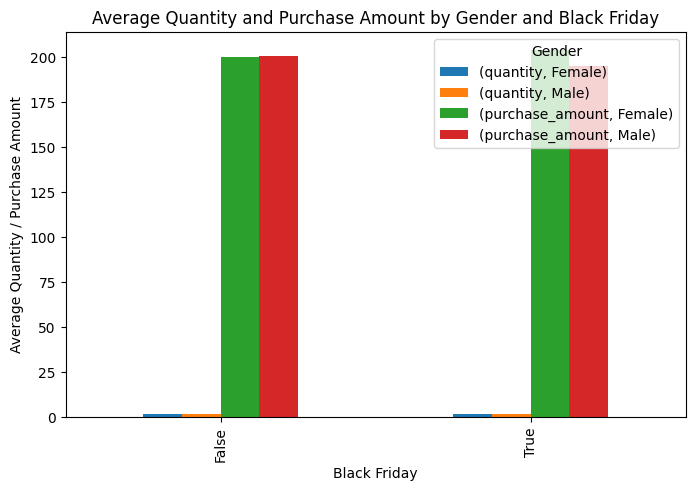

In [409]:
#split bar chart
y.unstack(level=0).plot(kind='bar', figsize=(8,5))
plt.title('Average Quantity and Purchase Amount by Gender and Black Friday')
plt.xlabel('Black Friday')
plt.ylabel('Average Quantity / Purchase Amount')
plt.legend(title='Gender', loc='upper right')
plt.show()

On average, males spend more than females during non discounted periods but females spend more during discounted periods.

In [410]:
# Which cities represent the most profitable markets?

df.head()

,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,weekend,black_friday
0,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35.0,99.92,1.0,99.92,Credit Card,01/12/2025,0.0,0,False
1,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40.0,138.03,1.0,138.03,PayPal,24/11/2025,5.0,0,False
2,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25.0,131.00,1.0,131.00,Credit Card,24/11/2025,14.0,0,False
3,18-25,Other,Miami,VIP,P3003,Sports,399.61,40.0,239.77,1.0,239.77,Credit Card,30/11/2025,23.0,1,True
4,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30.0,84.61,2.0,169.22,Debit Card,25/11/2025,2.0,0,False


In [411]:
total_sales_by_city=df.groupby(['city','age_group'])['purchase_amount'].sum().sort_values(ascending=False)
result=total_sales_by_city.head(10)
result

city           age_group
Seattle        36-45        376131.69
Houston        46-55        367602.80
New York       46-55        367201.04
San Francisco  46-55        364551.66
Miami          56+          362183.82
New York       18-25        362023.07
Houston        36-45        361962.42
Dallas         26-35        361486.10
San Francisco  18-25        361244.75
New York       26-35        360933.97
Name: purchase_amount, dtype: float64

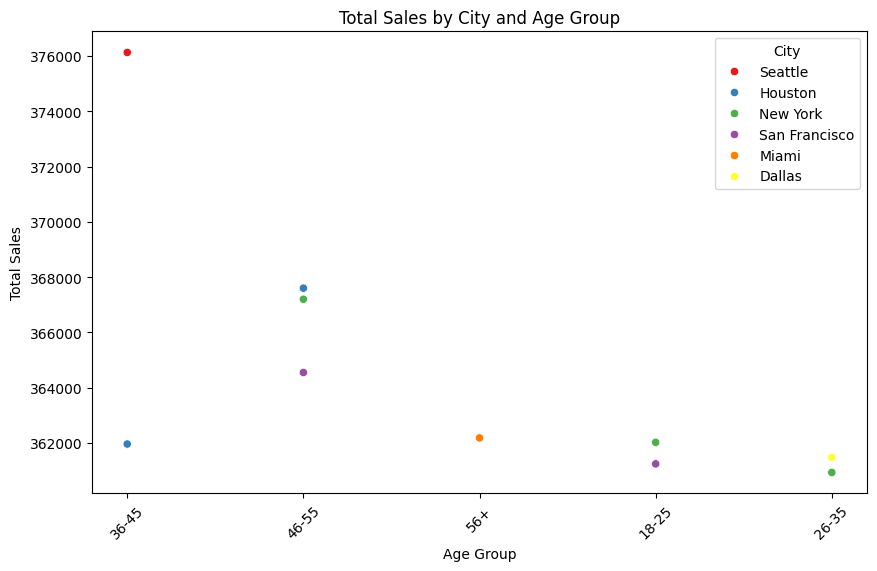

In [412]:
#plot scatter plot of total sales by city and age group
plt.figure(figsize=(10,6))
sns.scatterplot(x=result.index.get_level_values('age_group'), y=result.values, hue=result.index.get_level_values('city'), palette='Set1')
plt.title('Total Sales by City and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.legend(title='City', loc='upper right')
plt.xticks(rotation=45)
plt.show()